# what is backtracking : 
Backtracking is a recursive algorithmic technique used to solve problems by building a solution incrementally, one step at a time, and backtracking a path as soon as it find out  that it cannot lead to a valid solution.

At its heart, every backtracking algorithm follows a simple, recursive three-step process:

1. Choose: Make a choice from a set of available options.

2. Explore: Move forward recursively with that choice, trying to solve the rest of the problem.

3. Unchoose: If the exploration hits a dead end or doesn't lead to a valid solution, you backtrack. This means undoing the choice you just made so you can try another option from step 1.

- Core Idea: "Try → Fail → Undo → Try Again"
### Key Benefits of Backtracking:
- 🌿 Pruning — Cuts off invalid branches early, saving time vs brute force
- 🎯 Completeness — Guarantees finding a solution if one exists
- 💾 Space Efficient — Only stores the current path, not all possibilities
- 🔧 Flexible — Works well with constraint-based problems
- 🧠 Intuitive — Easy to model real-world decision-making problems
### When to Use Backtracking?
- When the problem involves making a sequence of decisions
- When you need to find all possible solutions or one valid solution
- When the problem has constraints that can eliminate large solution spaces early
- Classic signal: problems involving "find all combinations/permutations/arrangements"

### Template of backtracking 

'''
1. 
    def backtrack(result, current_path, other_parameters...):

        # 1. Base Case: Have we found a valid solution?
        if is_a_solution(current_path):
            # Add a copy of the path to our results
            result.append(list(current_path)) 
            return

    # 2. Iterate through all possible choices
    for choice in get_all_possible_choices():
        if is_valid(choice, current_path):
            
            # ---> Step 1: CHOOSE <---
            # Add the choice to our current path
            current_path.append(choice)
            
            # ---> Step 2: EXPLORE <---
            # Recursively call the function to explore further
            backtrack(result, current_path, other_parameters...)
            
            # ---> Step 3: UNCHOOSE (BACKTRACK) <---
            # This is CRITICAL. We remove the choice to try other paths.
            current_path.pop()

-  --- Initial Call ---
- result = []
- backtrack(result, [], other_parameters...)
- return result

'''

# Another backtracking template
- Backtracking is a general algorithm for finding all (or some) solutions to some computational problems which incrementally builds candidates to the solution and abandons a candidate ("backtracks") as soon as it determines that the candidate cannot lead to a valid solution.

- It is due to this backtracking behaviour, the backtracking algorithms are often much faster than the brute-force search algorithm, since it eliminates many unnecessary exploration.

######
---
```
def backtrack(candidate):
    if find_solution(candidate):
        output(candidate)
        return
    
    # iterate all possible candidates.
    for next_candidate in list_of_candidates:
        if is_valid(next_candidate):
            # try this partial candidate solution
            place(next_candidate)
            # given the candidate, explore further.
            backtrack(next_candidate)
            # backtrack
            remove(next_candidate)
```
---
- Overall, the enumeration of candidates is done in two levels:

1. at the first level, the function is implemented as recursion. At each occurrence of recursion, the function is one step further to the final solution.
2. as the second level, within the recursion, we have an iteration that allows us to explore all the candidates that are of the same progress to the final solution.


# popular  backtracking questions in Python
 1. 🧩 N-Queens Problem
 2. 🔢 Sudoku Solver
3. Rat in a Maze
4. Word Search
5. Subset Sum
6. Permutations, Combination Sum,
7. Generate Parentheses, 
8. Partition Equal Subset Sum,
9. Letter Tile Possibilities
10. Finding all permutations, combinations, subsets, 
11. graph coloring 
12. knights tour : Move a chess knight to visit every square once
13. crossword puzzles 
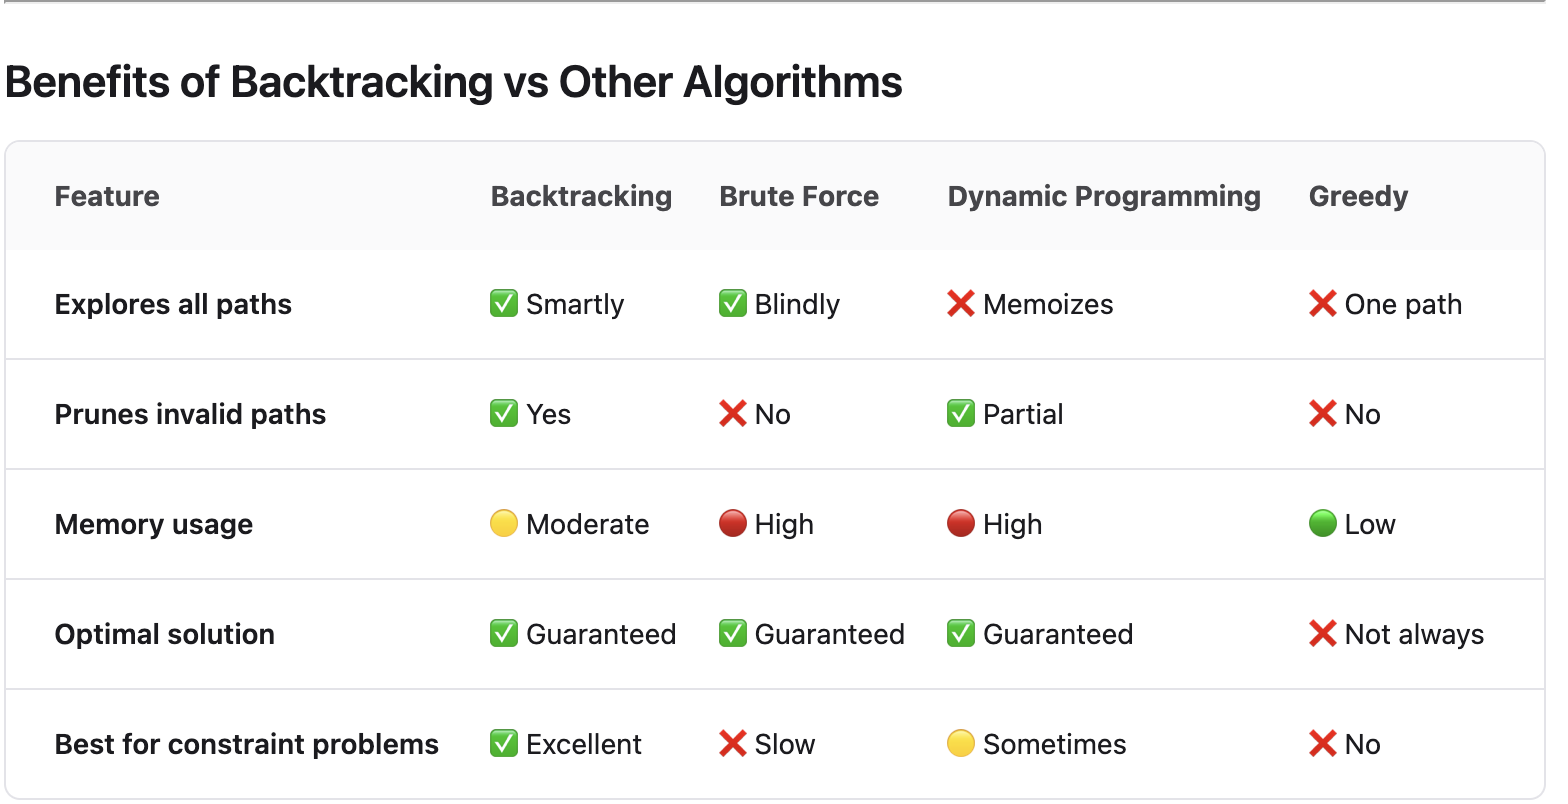


  ### lc 46 permutation: 
  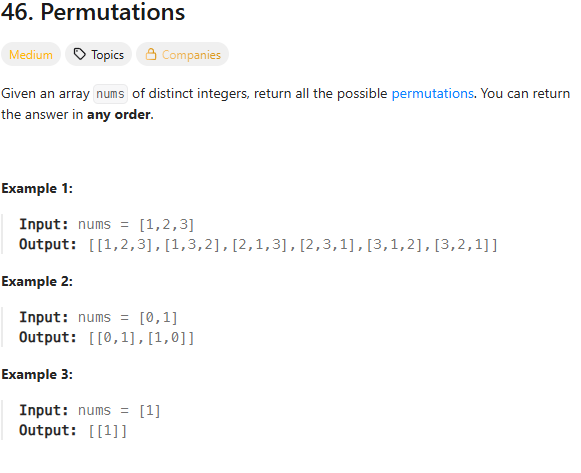

  


## How to implement a backtracking algorithm

Draw the tree, draw the tree, draw the tree!!!  Draw a state-space tree to visualize the problem.
#### When drawing the tree, bear in mind

- how do we know if we have reached a solution?
- how do we branch (generate possible children)?
## apply the following backtracking template:




- start_index is used to keep track of the current level of the state-space tree we are in.

- edge is the choice we make; the string a, b in the above state-space trees.
# come to the problem
Classic combinatorial search problem, we can solve it using 3-step system

1. Identify states

What state do we need to know whether we have reached a solution (and using it to construct a solution if the problem asks for it).
We need a state to keep track of the list of letters we have chosen for the current permutation
What state do we need to decide which child nodes should be visited next and which ones should be pruned?
We have to know what are the letters left that we can still use (since each letter can only be used once).

2. Draw the State-space Tree
3. DFS on the State-space tree

- A list to represent permutation constructed so far, path
-A list to record which letters are already used, used, used[i] == true means ith letter in the origin list has been used.


In [ ]:
def find_permutations(nums):
    """
    Finds all unique permutations of the numbers in the list 'nums'.
    """
    result = []
    
    def backtrack(current_path):
        # BASE CASE: If the current path is a full permutation
        if len(current_path) == len(nums):
            result.append(list(current_path)) # Add a copy!
            return

        # Iterate through the original numbers for our next choice
        for num in nums:
            # A choice is valid if the number is NOT already in our path
            if num not in current_path:
                
                # 1. CHOOSE
                current_path.append(num)
                
                # 2. EXPLORE
                backtrack(current_path)
                
                # 3. UNCHOOSE (This is the backtracking!)
                # After the above backtrack() call returns, we pop the number
                # to explore other possibilities.
                current_path.pop()

    # Start the process with an empty path
    backtrack([])
    return result

# --- Example Usage ---
my_nums = [1, 2, 3]
all_perms = find_permutations(my_nums)
print(all_perms)
# Output: [[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 1, 2], [3, 2, 1]]

In [ ]:
class Solution:
    def permute(self, l):
        def dfs(path, used, res):
            if len(path) == len(l):
                res.append(path[:]) # note [:] make a deep copy since otherwise we'd be append the same list over and over
                return

            for i, letter in enumerate(l):
                # skip used letters
                if used[i]:
                    continue
                # add letter to permutation, mark letter as used
                path.append(letter)
                used[i] = True
                dfs(path, used, res)# recursively call to the function
                # remove letter from permutation, mark letter as unused
                path.pop()
                used[i] = False
            
        res = []
        dfs([], [False] * len(l), res)
        return res